In [27]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated, Literal
from langchain_core.messages import HumanMessage, SystemMessage
import operator

In [28]:
class TweetEvaluationSchema(BaseModel):
    evaluation: Literal['approved','needs improvement']
    feedback: str

In [29]:
structured_evaluator_llm=generator.with_structured_output(TweetEvaluationSchema)

/Users/oscar/Desktop/LangGraph/langgraph/myenv/lib/python3.9/site-packages/langchain_openai/chat_models/base.py:1949: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [30]:
#State definition
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved','needs improvement']
    feedback: str
    iteration: int
    max_iterations: int
    
    tweet_history: list[str]
    feedback_history: Annotated[list[str], operator.add]
    

In [31]:
generator=ChatOpenAI(model='gpt-3.5-turbo',temperature=0.7)
evaluator=ChatOpenAI(model='gpt-4o',temperature=0.7)
optimizer=ChatOpenAI(model='gpt-4o-mini',temperature=0.7)

In [32]:
def generate_tweet(state: TweetState) -> TweetState:
    # prompt
    prompt = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    tweet = generator.invoke(prompt).content
    return {'tweet': tweet,'tweet_history': [tweet]}

In [33]:
def evaluate_tweet(state: TweetState) -> TweetState:
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    structured_response = structured_evaluator_llm.invoke(messages)
    return {'evaluation': structured_response.evaluation, 'feedback': structured_response.feedback, 'feedback_history': [structured_response.feedback]}
    

In [34]:
def optimize_tweet(state: TweetState) -> TweetState:
    # prompt
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    response = optimizer.invoke(messages).content
    iteration = state['iteration'] + 1
    return {'tweet': response, 'iteration': iteration, 'tweet_history': state['tweet_history'] + [response]}

In [38]:
def route_evaluation(state: TweetState) -> str:
    return 'approved' if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations'] else 'needs_optimization'

In [39]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation,{"approved": END, "needs_optimization": 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

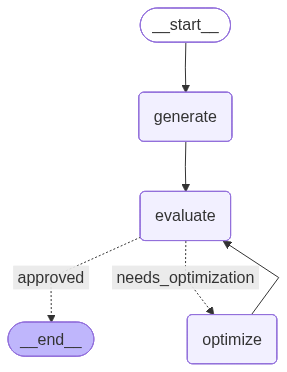

In [40]:
workflow

In [37]:
initial_state=TweetState(
    topic="The paradox of choice in modern dating apps",
    iteration=1,
    max_iterations=5
)
final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'The paradox of choice in modern dating apps', 'tweet': 'Modern dating apps have more options than a kid in a candy store, but end up leaving you more confused than a chameleon in a bag of Skittles. Swipe left, swipe right...oh wait, was that the one with the cute dog or the one who loves pineapple on pizza? 🍍🐶 #DatingDilemmas', 'evaluation': 'approved', 'feedback': 'This tweet is approved. It demonstrates strong originality by comparing modern dating apps to a kid in a candy store and a chameleon in a bag of Skittles, which is a fresh and creative analogy. The humor is evident in the confusion portrayed by the plethora of options on dating apps, adding a touch of relatability. The tweet is punchy and engaging, with a playful tone and relevant emojis. The reference to swiping left and right adds to the humor and ties back to the dating theme. The tweet is well-formatted, under 280 characters, and has the potential to be shared due to its witty and relatable content.', 'iterat

In [41]:
for tweet, feedback in zip(final_state['tweet_history'], final_state['feedback_history']):
    print(f"Tweet: {tweet}\nFeedback: {feedback}\n{'-'*50}")

Tweet: Modern dating apps have more options than a kid in a candy store, but end up leaving you more confused than a chameleon in a bag of Skittles. Swipe left, swipe right...oh wait, was that the one with the cute dog or the one who loves pineapple on pizza? 🍍🐶 #DatingDilemmas
Feedback: This tweet is approved. It demonstrates strong originality by comparing modern dating apps to a kid in a candy store and a chameleon in a bag of Skittles, which is a fresh and creative analogy. The humor is evident in the confusion portrayed by the plethora of options on dating apps, adding a touch of relatability. The tweet is punchy and engaging, with a playful tone and relevant emojis. The reference to swiping left and right adds to the humor and ties back to the dating theme. The tweet is well-formatted, under 280 characters, and has the potential to be shared due to its witty and relatable content.
--------------------------------------------------
